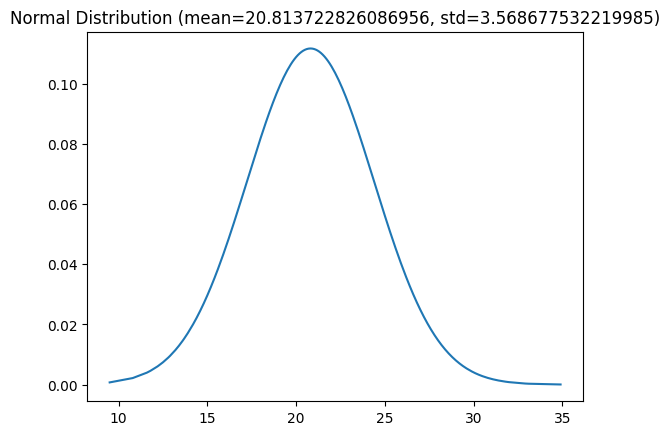

Probability is 0.12038563078530784


In [1]:
import sys
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import numpy as np
sys.path.append("/Users/gabriel/Desktop/Quant_Project/Quant-Summer-Project")

from data.fetcher import fetch_data
from data.cleaner import clean_data
from data.loader import add_event_column,filter_summer
from config.settings import HISTORICAL_START,HISTORICAL_END,DEFAULT_CITY
from scipy.stats import norm
from models.baseline import gaussian_probability


df_raw = fetch_data(HISTORICAL_START,HISTORICAL_END)


df_clean = clean_data(df_raw)


df_event = add_event_column(df_clean)


df_temp_summer = filter_summer(df_event)

df_temp_list = df_temp_summer["temperature_2m_max"].to_list()


df_sorted = sorted(df_temp_list)
P,my,sigma = gaussian_probability(df_sorted,25)

df_norm = norm.pdf(df_sorted,my,sigma)

plt.plot(df_sorted,df_norm)

plt.title(f'Normal Distribution (mean={my}, std={sigma})')
plt.show()
print(f"Probability is {P}")




